# FarmTech Solutions — Fase 5, Capítulo 1

**Entrega 1:** prever o rendimento de safra e encontrar padrões de produtividade.

- Luis Felipe Bardi — RM569479
- Karina Queiroz de Gennaro — RM570928
- Beatriz de Oliveira Ossola Ribeiro — RM570190

Usaremos `crop_yield.csv`. O nome do notebook mantém `pbl_fase4`, como pede o enunciado.

## 1. Carregar e conferir os dados

O CSV tem cultura, precipitação, duas medidas de umidade, temperatura e rendimento (`yield`).
A meta é prever `yield` usando as outras cinco colunas.

| Coluna no código | Significado |
|---|---|
| `crop` | Cultura |
| `precipitation` | Precipitação, na escala do CSV |
| `specific_humidity` | Umidade específica (g/kg) |
| `relative_humidity` | Umidade relativa (%) |
| `temperature` | Temperatura (°C) |
| `yield` | Rendimento, na escala do CSV |

**Unidades:** o enunciado informa t/ha, mas os valores de rendimento chegam a 203.399.
A escala da precipitação também precisa de confirmação. Preservamos os números do CSV;
as previsões e os erros ficam na **unidade original**, sem conversão.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.base import clone
from sklearn.cluster import KMeans, DBSCAN
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score, silhouette_score
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

SEED = 42
sns.set_theme(style='whitegrid')
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
# Abra a partir de Cap1/ ou src/, conforme as instruções do README.
root = Path.cwd()
if not (root / 'data/crop_yield.csv').exists():
    root = root.parent

data = pd.read_csv(root / 'data/crop_yield.csv').rename(columns={
    'Crop': 'crop',
    'Precipitation (mm day-1)': 'precipitation',
    'Specific Humidity at 2 Meters (g/kg)': 'specific_humidity',
    'Relative Humidity at 2 Meters (%)': 'relative_humidity',
    'Temperature at 2 Meters (C)': 'temperature',
    'Yield': 'yield',
})
climate_columns = ['precipitation', 'specific_humidity', 'relative_humidity', 'temperature']
features = ['crop'] + climate_columns
display(data.head())

,crop,precipitation,specific_humidity,relative_humidity,temperature,yield
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800


In [3]:
print('Linhas e colunas:', data.shape)
print('Valores ausentes:', data.isna().sum().sum())
print('Linhas duplicadas:', data.duplicated().sum())
display(data['crop'].value_counts().to_frame('Registros'))

# Cada combinação climática recebe um identificador.
groups = data.groupby(climate_columns, sort=False).ngroup()
print('Cenários climáticos diferentes:', groups.nunique())
assert not data.isna().any().any(), 'Revise os valores ausentes antes de continuar.'
assert not data.duplicated().any(), 'Revise as duplicatas antes de continuar.'

Linhas e colunas: (156, 6)
Valores ausentes: 0
Linhas duplicadas: 0


,Registros
crop,
"Cocoa, beans",39
Oil palm fruit,39
"Rice, paddy",39
"Rubber, natural",39


Cenários climáticos diferentes: 39


São **156 registros**, sem ausentes ou duplicatas, com **39 por cultura**.
As mesmas **39 combinações climáticas** aparecem nas quatro culturas.
Por isso, precisamos manter cada combinação inteira no treino ou no teste.

## 2. Separar treino e teste

Reservamos cerca de 20% dos cenários para o teste final. Usamos o restante para
explorar os dados e escolher o modelo. A semente 42 permite repetir a divisão.

In [4]:
X = data[features]
y = data['yield']
split = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
train_index, test_index = next(split.split(X, groups=groups))

X_train, X_test = X.iloc[train_index], X.iloc[test_index]
y_train, y_test = y.iloc[train_index], y.iloc[test_index]
train = data.iloc[train_index].copy()
train_groups = groups.iloc[train_index]

# Nenhum cenário pode aparecer dos dois lados.
assert set(train_groups).isdisjoint(groups.iloc[test_index])
print(f'Treino: {len(train)} registros, {train_groups.nunique()} cenários')
print(f'Teste: {len(X_test)} registros, {groups.iloc[test_index].nunique()} cenários')

Treino: 124 registros, 31 cenários
Teste: 32 registros, 8 cenários


## 3. Explorar o treino

Primeiro, comparamos o rendimento das culturas. Depois, observamos o clima
e sua relação com o rendimento. Os gráficos abaixo usam somente o treino.

In [5]:
# Esta função apenas salva e mostra os gráficos.
figures = root / 'docs/figures'
figures.mkdir(parents=True, exist_ok=True)

def show_plot(filename):
    plt.savefig(figures / filename, dpi=140, bbox_inches='tight')
    plt.show()
    plt.close()

display(train.describe().T)
display(train.groupby('crop')['yield'].agg(['mean', 'median', 'min', 'max']))

,count,mean,std,min,25%,50%,75%,max
precipitation,124.00,2434.59,270.47,1934.62,2249.70,2410.13,2686.20,2922.18
specific_humidity,124.00,18.20,0.30,17.54,18.01,18.28,18.40,18.70
relative_humidity,124.00,84.65,1.01,82.11,84.03,84.67,85.51,86.09
temperature,124.00,26.20,0.27,25.56,26.02,26.18,26.30,26.81
yield,124.00,55536.55,69589.30,5249.00,8281.50,18373.50,67518.75,202379.00


,mean,median,min,max
crop,,,,
"Cocoa, beans",8730.61,8848.00,5765,11560
Oil palm fruit,173675.00,172165.00,142425,202379
"Rice, paddy",32064.74,31101.00,25187,42550
"Rubber, natural",7675.84,7435.00,5249,10159


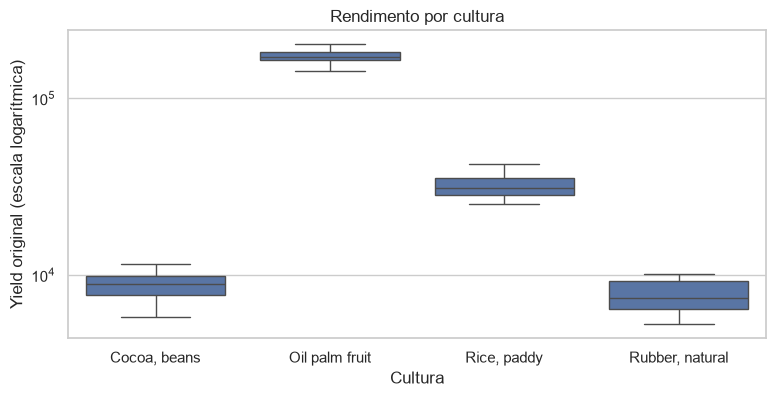

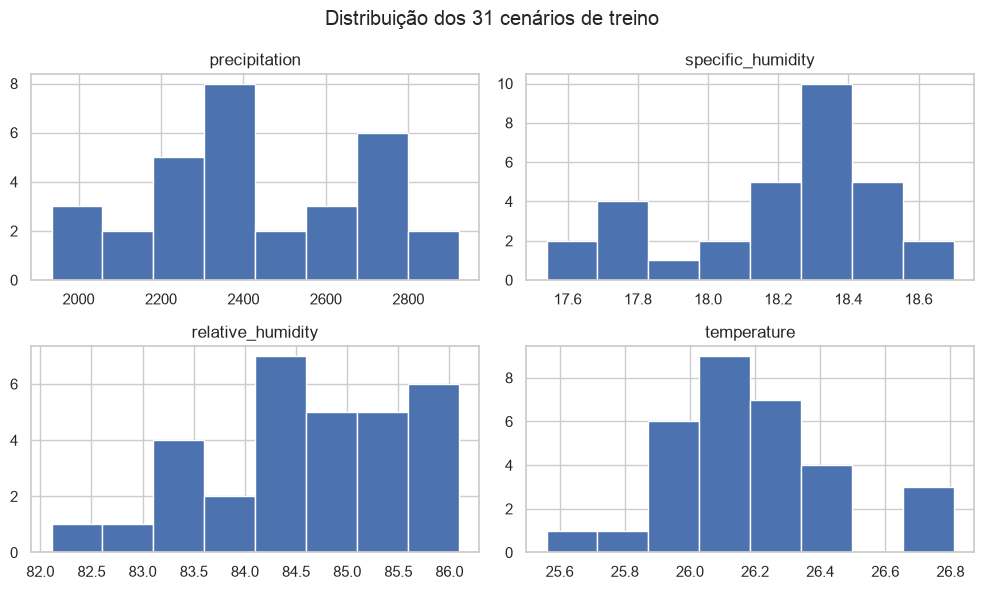

In [6]:
plt.figure(figsize=(9, 4))
sns.boxplot(data=train, x='crop', y='yield')
plt.yscale('log')  # Facilita comparar culturas com rendimentos muito diferentes.
plt.xlabel('Cultura')
plt.ylabel('Yield original (escala logarítmica)')
plt.title('Rendimento por cultura')
show_plot('01_rendimento_culturas.png')

climate = train[climate_columns].drop_duplicates()
climate.hist(bins=8, figsize=(10, 6))
plt.suptitle('Distribuição dos 31 cenários de treino')
plt.tight_layout()
show_plot('02_distribuicoes_clima.png')

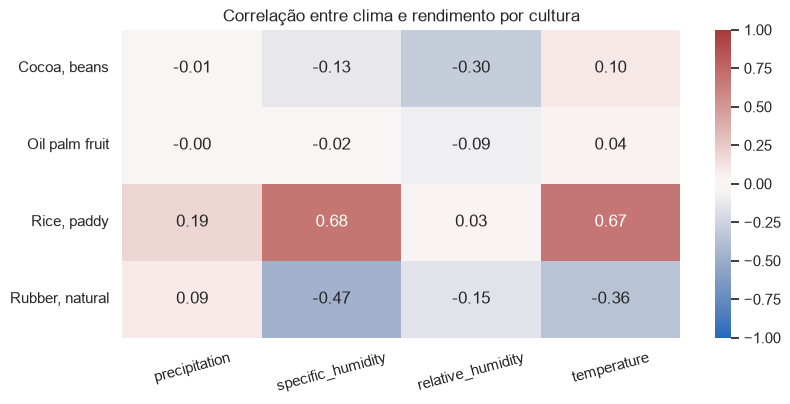

In [7]:
# Calculamos as correlações dentro de cada cultura.
correlations = {}
for crop, rows in train.groupby('crop'):
    correlations[crop] = rows[climate_columns].corrwith(rows['yield'])
correlations = pd.DataFrame(correlations).T

plt.figure(figsize=(9, 4))
sns.heatmap(correlations, annot=True, fmt='.2f', cmap='vlag', center=0, vmin=-1, vmax=1)
plt.title('Correlação entre clima e rendimento por cultura')
plt.xticks(rotation=15)
show_plot('03_correlacoes.png')

**O que encontramos:** dendê tem rendimentos muito maiores que as outras culturas.
No arroz, temperatura e umidade específica têm correlação positiva com o rendimento;
na borracha, negativa. Essas relações não provam que o clima causou a diferença.

## 4. Encontrar grupos de cenários

O **K-Means** reúne cenários com clima parecido. Padronizamos as quatro medidas
para que nenhuma domine apenas por usar números maiores.
Testamos de 2 a 6 grupos e escolhemos a maior **silhueta**, uma medida de separação.
Cultura e rendimento não entram no agrupamento.

In [8]:
scaled_climate = StandardScaler().fit_transform(climate)
scores = []
for k in range(2, 7):
    model = KMeans(n_clusters=k, n_init=30, random_state=SEED)
    labels = model.fit_predict(scaled_climate)
    scores.append({'k': k, 'Silhueta': silhouette_score(scaled_climate, labels)})

cluster_scores = pd.DataFrame(scores).set_index('k')
best_k = int(cluster_scores['Silhueta'].idxmax())
kmeans = KMeans(n_clusters=best_k, n_init=30, random_state=SEED)
climate = climate.copy()
climate['cluster'] = kmeans.fit_predict(scaled_climate)
display(cluster_scores)
print('Quantidade de grupos escolhida:', best_k)

,Silhueta
k,
2,0.38
3,0.39
4,0.41
5,0.37
6,0.36


Quantidade de grupos escolhida: 4


,Cenários
cluster,
0,9
1,2
2,6
3,14


,precipitation,specific_humidity,relative_humidity,temperature
cluster,,,,
0,2139.38,17.92,83.73,26.13
1,2465.82,17.66,84.81,25.66
2,2345.09,18.50,83.95,26.62
3,2658.26,18.33,85.51,26.14


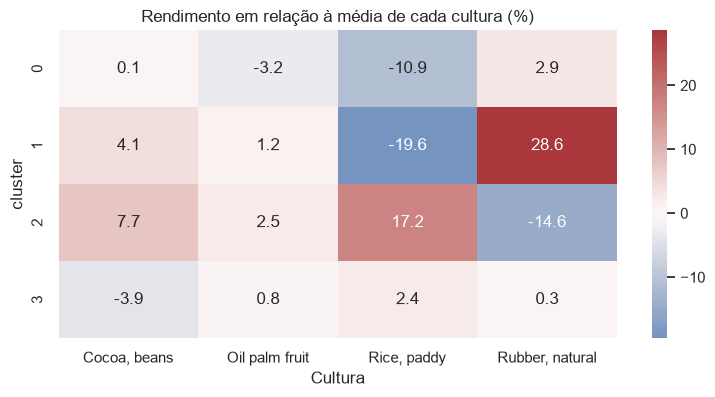

In [9]:
# Cada cultura recebe o grupo correspondente às suas condições climáticas.
clustered = train.merge(climate, on=climate_columns, validate='many_to_one')
display(climate.groupby('cluster').size().to_frame('Cenários'))
display(climate.groupby('cluster')[climate_columns].mean())

crop_means = train.groupby('crop')['yield'].mean()
cluster_yields = clustered.pivot_table(index='cluster', columns='crop', values='yield')
relative_yields = 100 * (cluster_yields / crop_means - 1)

plt.figure(figsize=(9, 4))
sns.heatmap(relative_yields, annot=True, fmt='.1f', cmap='vlag', center=0)
plt.title('Rendimento em relação à média de cada cultura (%)')
plt.xlabel('Cultura')
show_plot('04_produtividade_clusters.png')

Foram encontrados **4 grupos**, com 9, 2, 6 e 14 cenários.
No grupo 2, arroz fica **17,2% acima** da sua média e borracha **14,6% abaixo**.
Isso sugere respostas diferentes ao mesmo clima. O grupo 1 tem só dois cenários,
então suas médias são menos confiáveis. Os números dos grupos não indicam qualidade.

## 5. Identificar cenários discrepantes

O **DBSCAN** identifica cenários isolados no espaço climático. O rótulo `-1`
indica um possível outlier. Usamos `eps=1.5` e `min_samples=4` como ponto de partida.
A contagem depende desses parâmetros; uma sinalização não comprova erro no dado.

In [10]:
dbscan = DBSCAN(eps=1.5, min_samples=4)
climate['outlier'] = dbscan.fit_predict(scaled_climate) == -1
outliers = climate.loc[climate['outlier'], climate_columns]
display(outliers)
print('Cenários discrepantes:', len(outliers))

,precipitation,specific_humidity,relative_humidity,temperature
1,1938.42,17.54,82.11,26.11
3,2592.35,17.61,85.07,25.56


Cenários discrepantes: 2


O DBSCAN sinalizou **2 cenários**, que aparecem em **8 registros** entre as culturas.
Mantemos esses registros nos modelos: eles podem representar condições reais.

## 6. Comparar cinco modelos de regressão

| Modelo | Ideia principal |
|---|---|
| Regressão Linear | Aprende uma relação linear entre entradas e rendimento |
| KNN | Usa os exemplos mais próximos |
| SVR | Aprende relações não lineares com uma margem de erro |
| Árvore de Decisão | Divide os dados usando regras |
| Random Forest | Combina várias árvores |

A **validação cruzada** divide o treino em cinco partes e alterna a parte usada
para avaliar. Mantemos cenários iguais juntos e escolhemos o menor **RMSE médio**.
Uma pequena busca testa as configurações de cada modelo. O teste final fica reservado.

### Preparar as entradas

`StandardScaler` ajusta as escalas numéricas. `OneHotEncoder` transforma culturas
em colunas numéricas. O `Pipeline` aprende essas transformações apenas no treino
de cada divisão. Também ajustamos a escala do alvo para ajudar o SVR;
as previsões retornam automaticamente à unidade original.

No KNN e no SVR, mantemos uma coluna para cada cultura. Assim, nenhuma cultura
fica artificialmente mais próxima das outras por causa da codificação.

In [11]:
preprocessing = ColumnTransformer([
    ('climate', StandardScaler(), climate_columns),
    ('crop', OneHotEncoder(drop='first', sparse_output=False), ['crop']),
])

def make_model(regressor):
    prepared = clone(preprocessing)
    # KNN e SVR precisam da mesma distância entre quaisquer culturas.
    if isinstance(regressor, (KNeighborsRegressor, SVR)):
        prepared.set_params(crop__drop=None)
    return Pipeline([
        ('prepare', prepared),
        ('model', TransformedTargetRegressor(
            regressor=regressor, transformer=StandardScaler(),
        )),
    ])

cv = GroupKFold(n_splits=5, shuffle=True, random_state=SEED)
folds = list(cv.split(X_train, groups=train_groups))

### Definir os modelos e as configurações a testar

Por exemplo, no KNN comparamos 3, 5 e 9 vizinhos.
Todos os modelos serão avaliados nas mesmas cinco divisões.

In [12]:
models = {
    'Regressão Linear': (LinearRegression(), {}),
    'KNN': (KNeighborsRegressor(), {
        'n_neighbors': [3, 5, 9], 'weights': ['uniform', 'distance'],
    }),
    'SVR': (SVR(), {
        'C': [1, 10, 100], 'gamma': ['scale', 0.1], 'epsilon': [0.01, 0.1],
    }),
    'Árvore de Decisão': (DecisionTreeRegressor(random_state=SEED), {
        'max_depth': [2, 4, None], 'min_samples_leaf': [2, 5, 10],
    }),
    'Random Forest': (RandomForestRegressor(n_estimators=200, random_state=SEED), {
        'max_depth': [3, None], 'min_samples_leaf': [1, 3, 5],
    }),
}

In [13]:
fitted_models = {}
validation = []
for name, (regressor, options) in models.items():
    # O prefixo indica onde está o regressor dentro do Pipeline.
    grid = {'model__regressor__' + key: values for key, values in options.items()}
    search = GridSearchCV(make_model(regressor), grid, cv=folds,
                          scoring='neg_root_mean_squared_error', error_score='raise')
    search.fit(X_train, y_train)
    fitted_models[name] = search.best_estimator_
    validation.append({'Modelo': name, 'RMSE validação': -search.best_score_})

validation = pd.DataFrame(validation).set_index('Modelo').sort_values('RMSE validação')
best_name = validation.index[0]
best_model = fitted_models[best_name]
display(validation)
print('Modelo escolhido:', best_name)

,RMSE validação
Modelo,
Random Forest,7281.70
Regressão Linear,8052.99
Árvore de Decisão,8129.28
SVR,10517.05
KNN,14897.31


Modelo escolhido: Random Forest


### Avaliar no teste

- **MAE:** erro absoluto médio. Menor é melhor.
- **RMSE:** dá mais peso aos erros grandes. Menor é melhor.
- **R²:** compara com prever a média dos valores avaliados; pode ser negativo.

Também prevemos a **média de treino de cada cultura** como referência simples.
Ela ajuda a verificar se incluir clima melhora a previsão.

In [14]:
def metrics(actual, predicted):
    return {
        'MAE': mean_absolute_error(actual, predicted),
        'RMSE': root_mean_squared_error(actual, predicted),
        'R²': r2_score(actual, predicted),
    }

test_results = {}
for name, model in fitted_models.items():
    test_results[name] = metrics(y_test, model.predict(X_test))
baseline = X_test['crop'].map(crop_means)
test_results['Média por cultura'] = metrics(y_test, baseline)
test_results = pd.DataFrame(test_results).T
display(test_results)

,MAE,RMSE,R²
Regressão Linear,5857.98,8601.44,0.99
KNN,5321.94,7781.54,0.99
SVR,7612.26,12417.50,0.97
Árvore de Decisão,5356.15,9103.25,0.98
Random Forest,5913.64,10001.66,0.98
Média por cultura,5807.94,9244.69,0.98


In [15]:
predictions = X_test[['crop']].copy()
predictions['yield'] = y_test
predictions['prediction'] = best_model.predict(X_test)
predictions['baseline'] = baseline

crop_results = []
for crop, rows in predictions.groupby('crop'):
    result = metrics(rows['yield'], rows['prediction'])
    result['Cultura'] = crop
    result['MAE referência'] = mean_absolute_error(rows['yield'], rows['baseline'])
    crop_results.append(result)
crop_results = pd.DataFrame(crop_results).set_index('Cultura')
display(crop_results)

,MAE,RMSE,R²,MAE referência
Cultura,,,,
"Cocoa, beans",1985.11,2284.14,-0.07,1832.72
Oil palm fruit,16140.39,19203.80,-0.81,15493.75
"Rice, paddy",4012.07,4762.09,-0.04,4284.25
"Rubber, natural",1517.00,1857.93,-0.43,1621.04


**Resultado:** Random Forest venceu na validação. No teste, seu RMSE foi
**10.001,66**, contra **9.244,69** da média por cultura: um erro **8,19% maior**.
O ganho de usar clima não se confirmou para o modelo escolhido.

O R² global foi **0,9815**, mas ficou negativo nas quatro culturas separadamente.
O valor global alto reflete principalmente a diferença de escala entre culturas.
Mantemos a escolha feita na validação, sem trocar de modelo com base no teste.

## 7. Fazer uma previsão

Usamos um registro do teste para mostrar entradas, previsão e valor observado.
O modelo recebe somente cultura e clima.

In [16]:
example = X_test.iloc[[0]]
display(example)
prediction = best_model.predict(example)[0]
observed = y_test.loc[example.index[0]]
print(f'Previsão: {prediction:.2f}')
print(f'Valor observado: {observed:.2f}')
print(f'Erro absoluto: {abs(prediction - observed):.2f}')

,crop,precipitation,specific_humidity,relative_humidity,temperature
4,"Cocoa, beans",2344.72,17.61,84.12,25.76


Previsão: 9131.06
Valor observado: 8800.00
Erro absoluto: 331.06


## 8. Conclusões

**O que funcionou:** comparamos cinco algoritmos sem misturar cenários entre treino
e teste. Encontramos quatro grupos climáticos e dois cenários discrepantes.

**Limites:** o modelo escolhido não superou a média por cultura no teste.
Há apenas 39 cenários, sem datas, talhões ou medidas de solo. As unidades precisam
de confirmação. Os resultados não garantem desempenho em outra safra.

**Próximo passo:** confirmar as unidades e coletar mais safras para validar os modelos.

Referências: CSV e enunciado da FIAP;
[pipelines](https://scikit-learn.org/stable/common_pitfalls.html),
[validação cruzada](https://scikit-learn.org/stable/modules/cross_validation.html) e
[clusterização](https://scikit-learn.org/stable/modules/clustering.html) no scikit-learn.

### Salvar as tabelas

Os resultados já aparecem acima. Esta célula salva cópias em CSV para consulta.

In [17]:
results = root / 'docs/results'
results.mkdir(parents=True, exist_ok=True)
validation.to_csv(results / 'metrics_cv.csv')
test_results.to_csv(results / 'metrics_test.csv', index_label='Modelo')
crop_results.to_csv(results / 'metrics_by_crop.csv')
predictions.to_csv(results / 'predictions_test.csv', index_label='row_id')
cluster_scores.to_csv(results / 'kmeans_selection.csv')
relative_yields.to_csv(results / 'cluster_productivity.csv')
outliers.to_csv(results / 'outlier_records.csv', index_label='row_id')